# LAPORAN FINAL PROJECT MACHINE LEARNING (TK075)
## HeartGuard ML: Deteksi Dini Penyakit Jantung Menggunakan Support Vector Machine (SVM) dan XGBoost Classifier dengan 5x Hyperparameter Tuning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Badwolf90/UAS_Machine_Learning/blob/main/notebooks/Heart_Disease_Prediction_UAS.ipynb)

---
### **Informasi Mata Kuliah & Kelompok**
- **Mata Kuliah:** Machine Learning (TK075)
- **SKS:** 2 SKS | **Program Studi:** Teknik Komputer
- **Instansi:** Universitas Amikom Yogyakarta
- **Topik:** Classification - Heart Disease Prediction
- **Dataset:** Kaggle Heart Disease Dataset (Cleveland / UCI)
- **Link Kaggle:** [Kaggle Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)
- **Model ML:** Support Vector Machine (SVM) vs XGBoost Classifier
---

### **1. Setup Environment & Installation**
Menginstall library yang dibutuhkan saat dijalankan di lingkungan Google Colab / Jupyter VS Code.

In [27]:
# Install dependencies (Gunakan %pip agar terinstall ke kernel aktif)
%pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### **2. Import Library & Dark Styling Setup**

In [28]:
import sys
import subprocess
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Auto check & install xgboost jika belum terinstall di kernel ini
try:
    from xgboost import XGBClassifier
except ImportError:
    print("Package xgboost belum terdeteksi. Menginstall secara otomatis ke kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn", "joblib"])
    from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

# Configure Vercel & Notion Style Dark Theme untuk Visualisasi Matplotlib
plt.style.use('dark_background')
plt.rcParams.update({
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'sans-serif'],
    'font.size': 11,
    'figure.facecolor': '#0a0a0c',
    'axes.facecolor': '#121216',
    'axes.edgecolor': '#27272a',
    'axes.labelcolor': '#ededed',
    'xtick.color': '#a1a1aa',
    'ytick.color': '#a1a1aa',
    'grid.color': '#27272a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'text.color': '#ededed',
    'savefig.facecolor': '#0a0a0c',
    'savefig.edgecolor': '#0a0a0c'
})

print("Setup Environment & Styling Berhasil!")

Setup Environment & Styling Berhasil!


### **3. Load & Eksplorasi Dataset**
Membaca dataset `heart.csv` (Kaggle Heart Disease Dataset). Jika file lokal tidak ditemukan (seperti saat pertama buka di Colab), dataset akan otomatis diunduh dari mirror UCI/Kaggle.

In [29]:
# Setup direktori
os.makedirs('dataset', exist_ok=True)
os.makedirs(os.path.join('static', 'images'), exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Cari dataset heart.csv di direktori lokal atau parent directory
possible_paths = [
    os.path.join('dataset', 'heart.csv'),
    os.path.join('..', 'dataset', 'heart.csv'),
    'heart.csv'
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path:
    print(f"Memuat dataset dari file lokal: {data_path}")
    df = pd.read_csv(data_path)
else:
    print("File lokal tidak ditemukan. Memuat Kaggle Heart Disease Dataset dari mirror URL...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    df = pd.read_csv(url, names=cols, na_values='?')
    df = df.dropna()
    df['target'] = (df['target'] > 0).astype(int)
    data_path = os.path.join('dataset', 'heart.csv')
    df.to_csv(data_path, index=False)

print(f"Ukuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Memuat dataset dari file lokal: dataset\heart.csv
Ukuran Dataset: 297 baris, 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### **4. Preprocessing & Data Splitting**
- Pemisahan Fitur ($X$) dan Target ($y$)
- Stratified Train-Test Split (80% Data Latih, 20% Data Uji)
- Feature Scaling menggunakan `StandardScaler` (Disimpan sebagai DataFrame berfitur lengkap)

In [30]:
X = df.drop(columns=['target'])
y = df['target']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Dipertahankan nama kolomnya)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Data Latih (X_train): {X_train_scaled.shape}")
print(f"Data Uji (X_test)  : {X_test_scaled.shape}")

Data Latih (X_train): (237, 13)
Data Uji (X_test)  : (60, 13)


### **5. Eksperimen 5x Run Hyperparameter Tuning: Support Vector Machine (SVM)**

In [31]:
svm_experiments = [
    {"exp": 1, "name": "SVM Exp 1 (Linear, C=0.01)", "params": {"kernel": "linear", "C": 0.01, "probability": True}},
    {"exp": 2, "name": "SVM Exp 2 (Linear, C=1.0)", "params": {"kernel": "linear", "C": 1.0, "probability": True}},
    {"exp": 3, "name": "SVM Exp 3 (RBF, C=1.0, gamma='scale')", "params": {"kernel": "rbf", "C": 1.0, "gamma": "scale", "probability": True}},
    {"exp": 4, "name": "SVM Exp 4 (RBF, C=10.0, gamma=0.01)", "params": {"kernel": "rbf", "C": 10.0, "gamma": 0.01, "probability": True}},
    {"exp": 5, "name": "SVM Exp 5 (Poly deg=3, C=1.0)", "params": {"kernel": "poly", "degree": 3, "C": 1.0, "probability": True}},
]

svm_results = []
svm_best_model = None
svm_best_acc = 0.0

for item in svm_experiments:
    model = SVC(**item["params"], random_state=42)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    res = {
        "Exp": item["exp"],
        "Model": "SVM",
        "Config": item["name"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "model_obj": model,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    svm_results.append(res)
    if acc > svm_best_acc:
        svm_best_acc = acc
        svm_best_model = res

df_svm_res = pd.DataFrame(svm_results).drop(columns=['model_obj', 'y_pred', 'y_prob'])
df_svm_res

,Exp,Model,Config,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,SVM,"SVM Exp 1 (Linear, C=0.01)",0.866667,0.916667,0.785714,0.846154,0.960938
1,2,SVM,"SVM Exp 2 (Linear, C=1.0)",0.850000,0.880000,0.785714,0.830189,0.953125
2,3,SVM,"SVM Exp 3 (RBF, C=1.0, gamma='scale')",0.850000,0.880000,0.785714,0.830189,0.954241
3,4,SVM,"SVM Exp 4 (RBF, C=10.0, gamma=0.01)",0.850000,0.880000,0.785714,0.830189,0.956473
4,5,SVM,"SVM Exp 5 (Poly deg=3, C=1.0)",0.850000,0.880000,0.785714,0.830189,0.936384


### **6. Eksperimen 5x Run Hyperparameter Tuning: XGBoost Classifier**

In [32]:
xgb_experiments = [
    {"exp": 1, "name": "XGB Exp 1 (n_est=50, depth=3, lr=0.01)", "params": {"n_estimators": 50, "max_depth": 3, "learning_rate": 0.01}},
    {"exp": 2, "name": "XGB Exp 2 (n_est=100, depth=3, lr=0.1)", "params": {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1}},
    {"exp": 3, "name": "XGB Exp 3 (n_est=100, depth=5, lr=0.1)", "params": {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1}},
    {"exp": 4, "name": "XGB Exp 4 (n_est=200, depth=4, lr=0.05, sub=0.8)", "params": {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8}},
    {"exp": 5, "name": "XGB Exp 5 (n_est=300, depth=6, lr=0.01, sub=0.9, col=0.8)", "params": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.8}},
]

xgb_results = []
xgb_best_model = None
xgb_best_acc = 0.0

for item in xgb_experiments:
    model = XGBClassifier(**item["params"], random_state=42, eval_metric='logloss')
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    res = {
        "Exp": item["exp"],
        "Model": "XGBoost",
        "Config": item["name"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "model_obj": model,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    xgb_results.append(res)
    if acc > xgb_best_acc:
        xgb_best_acc = acc
        xgb_best_model = res

df_xgb_res = pd.DataFrame(xgb_results).drop(columns=['model_obj', 'y_pred', 'y_prob'])
df_xgb_res

,Exp,Model,Config,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,XGBoost,"XGB Exp 1 (n_est=50, depth=3, lr=0.01)",0.816667,0.904762,0.678571,0.775510,0.918527
1,2,XGBoost,"XGB Exp 2 (n_est=100, depth=3, lr=0.1)",0.816667,0.840000,0.750000,0.792453,0.902902
2,3,XGBoost,"XGB Exp 3 (n_est=100, depth=5, lr=0.1)",0.833333,0.846154,0.785714,0.814815,0.914062
3,4,XGBoost,"XGB Exp 4 (n_est=200, depth=4, lr=0.05, sub=0.8)",0.866667,0.884615,0.821429,0.851852,0.920759
4,5,XGBoost,"XGB Exp 5 (n_est=300, depth=6, lr=0.01, sub=0....",0.850000,0.880000,0.785714,0.830189,0.917411


### **7. Perbandingan Keseluruhan Hasil Eksperimen**

In [33]:
all_res = pd.concat([df_svm_res, df_xgb_res], ignore_index=True)
all_res.to_csv(os.path.join('results', 'experiment_results.csv'), index=False)
all_res

,Exp,Model,Config,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,SVM,"SVM Exp 1 (Linear, C=0.01)",0.866667,0.916667,0.785714,0.846154,0.960938
1,2,SVM,"SVM Exp 2 (Linear, C=1.0)",0.850000,0.880000,0.785714,0.830189,0.953125
2,3,SVM,"SVM Exp 3 (RBF, C=1.0, gamma='scale')",0.850000,0.880000,0.785714,0.830189,0.954241
3,4,SVM,"SVM Exp 4 (RBF, C=10.0, gamma=0.01)",0.850000,0.880000,0.785714,0.830189,0.956473
4,5,SVM,"SVM Exp 5 (Poly deg=3, C=1.0)",0.850000,0.880000,0.785714,0.830189,0.936384
5,1,XGBoost,"XGB Exp 1 (n_est=50, depth=3, lr=0.01)",0.816667,0.904762,0.678571,0.775510,0.918527
6,2,XGBoost,"XGB Exp 2 (n_est=100, depth=3, lr=0.1)",0.816667,0.840000,0.750000,0.792453,0.902902
7,3,XGBoost,"XGB Exp 3 (n_est=100, depth=5, lr=0.1)",0.833333,0.846154,0.785714,0.814815,0.914062
8,4,XGBoost,"XGB Exp 4 (n_est=200, depth=4, lr=0.05, sub=0.8)",0.866667,0.884615,0.821429,0.851852,0.920759
9,5,XGBoost,"XGB Exp 5 (n_est=300, depth=6, lr=0.01, sub=0....",0.850000,0.880000,0.785714,0.830189,0.917411


### **8. Visualisasi 1: Progres Hyperparameter Tuning**

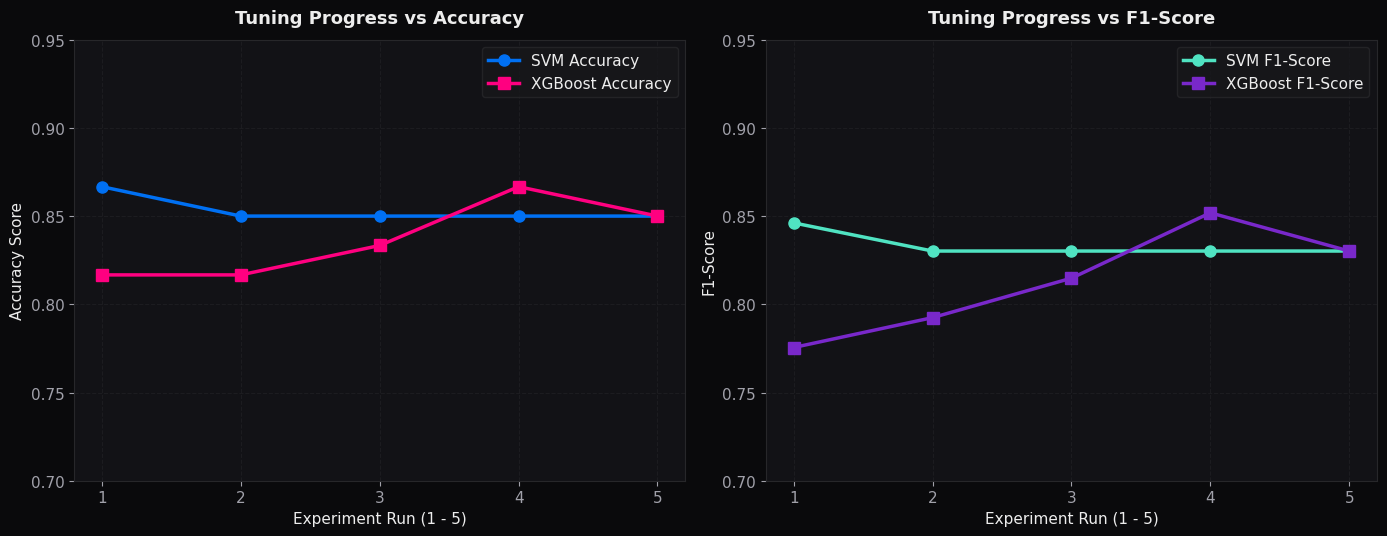

In [34]:
img_dir = os.path.join('static', 'images')
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
exps = [1, 2, 3, 4, 5]

ax[0].plot(exps, df_svm_res['Accuracy'], marker='o', markersize=8, linewidth=2.5, label='SVM Accuracy', color='#0070f3')
ax[0].plot(exps, df_xgb_res['Accuracy'], marker='s', markersize=8, linewidth=2.5, label='XGBoost Accuracy', color='#ff0080')
ax[0].set_title('Tuning Progress vs Accuracy', fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel('Experiment Run (1 - 5)')
ax[0].set_ylabel('Accuracy Score')
ax[0].set_xticks(exps)
ax[0].set_ylim(0.70, 0.95)
ax[0].legend(frameon=True, facecolor='#18181b', edgecolor='#27272a')
ax[0].grid(True)

ax[1].plot(exps, df_svm_res['F1-Score'], marker='o', markersize=8, linewidth=2.5, label='SVM F1-Score', color='#50e3c2')
ax[1].plot(exps, df_xgb_res['F1-Score'], marker='s', markersize=8, linewidth=2.5, label='XGBoost F1-Score', color='#7928ca')
ax[1].set_title('Tuning Progress vs F1-Score', fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel('Experiment Run (1 - 5)')
ax[1].set_ylabel('F1-Score')
ax[1].set_xticks(exps)
ax[1].set_ylim(0.70, 0.95)
ax[1].legend(frameon=True, facecolor='#18181b', edgecolor='#27272a')
ax[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'hyperparameter_tuning_experiments.png'), dpi=300, bbox_inches='tight')
plt.show()

### **9. Visualisasi 2: Confusion Matrices (Best SVM vs Best XGBoost)**

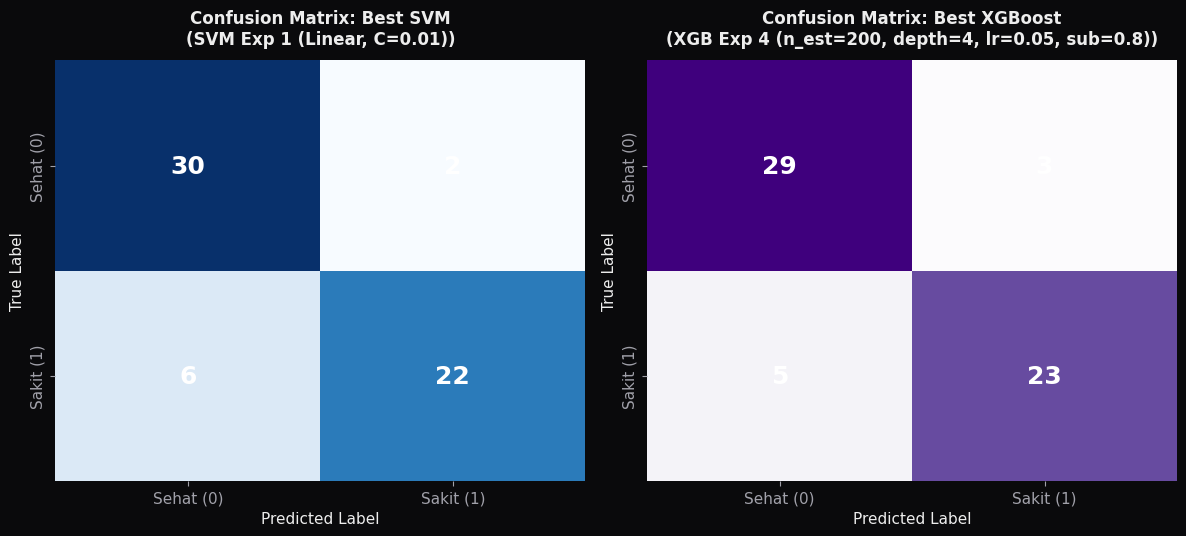

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
cm_svm = confusion_matrix(y_test, svm_best_model['y_pred'])
cm_xgb = confusion_matrix(y_test, xgb_best_model['y_pred'])

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 18, "weight": "bold", "color": "#ffffff"})
ax[0].set_title(f"Confusion Matrix: Best SVM\n({svm_best_model['Config']})", fontsize=12, fontweight='bold', pad=12)
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].set_xticklabels(['Sehat (0)', 'Sakit (1)'])
ax[0].set_yticklabels(['Sehat (0)', 'Sakit (1)'])

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', ax=ax[1], cbar=False, annot_kws={"size": 18, "weight": "bold", "color": "#ffffff"})
ax[1].set_title(f"Confusion Matrix: Best XGBoost\n({xgb_best_model['Config']})", fontsize=12, fontweight='bold', pad=12)
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].set_xticklabels(['Sehat (0)', 'Sakit (1)'])
ax[1].set_yticklabels(['Sehat (0)', 'Sakit (1)'])

plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

### **10. Visualisasi 3: Kurva ROC-AUC**

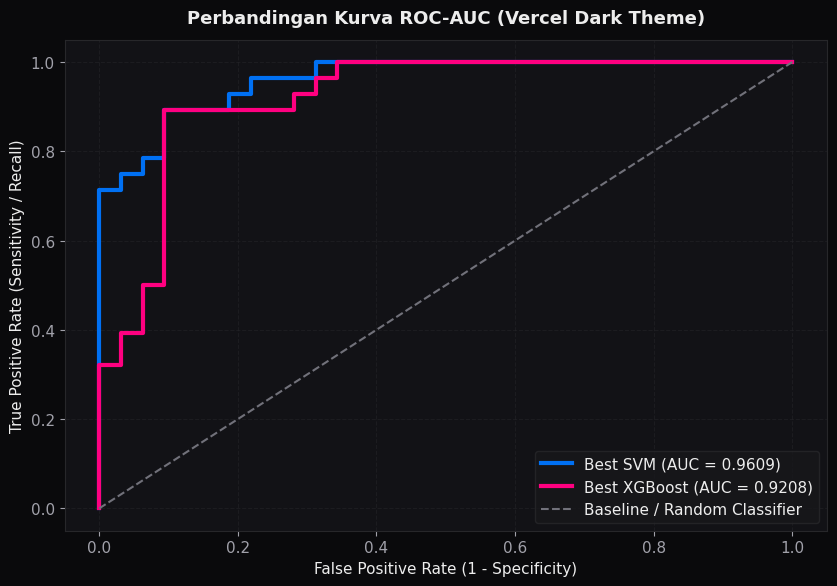

In [36]:
fig, ax = plt.subplots(figsize=(8.5, 6))
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_best_model['y_prob'])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_best_model['y_prob'])

ax.plot(fpr_svm, tpr_svm, label=f"Best SVM (AUC = {svm_best_model['ROC-AUC']:.4f})", color='#0070f3', linewidth=3)
ax.plot(fpr_xgb, tpr_xgb, label=f"Best XGBoost (AUC = {xgb_best_model['ROC-AUC']:.4f})", color='#ff0080', linewidth=3)
ax.plot([0, 1], [0, 1], '--', label='Baseline / Random Classifier', color='#71717a', linewidth=1.5)

ax.set_title('Perbandingan Kurva ROC-AUC (Vercel Dark Theme)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.legend(loc='lower right', frameon=True, facecolor='#18181b', edgecolor='#27272a')
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'roc_auc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

### **11. Visualisasi 4: Feature Importance Analysis (XGBoost)**

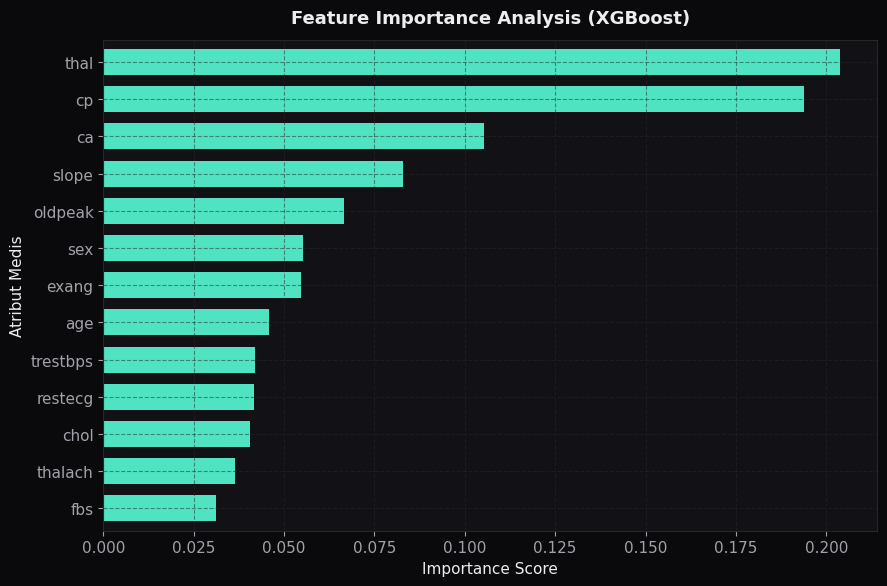

In [37]:
importances = xgb_best_model['model_obj'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = feat_imp.plot(kind='barh', color='#50e3c2', ax=ax, width=0.7)
ax.set_title('Feature Importance Analysis (XGBoost)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
ax.set_ylabel('Atribut Medis')
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

### **12. Save Models & Scaler**
Menyimpan model terbaik dan scaler untuk inference / aplikasi web.

In [38]:
joblib.dump(svm_best_model['model_obj'], os.path.join('models', 'svm_model.joblib'))
joblib.dump(xgb_best_model['model_obj'], os.path.join('models', 'xgb_model.joblib'))
joblib.dump(scaler, os.path.join('models', 'scaler.joblib'))

print("Model SVM Terbaik:", svm_best_model['Config'])
print("Model XGBoost Terbaik:", xgb_best_model['Config'])
print("Model dan Scaler Berhasil Disimpan ke Folder 'models/'!")

Model SVM Terbaik: SVM Exp 1 (Linear, C=0.01)
Model XGBoost Terbaik: XGB Exp 4 (n_est=200, depth=4, lr=0.05, sub=0.8)
Model dan Scaler Berhasil Disimpan ke Folder 'models/'!
